In [1]:
%reload_ext autoreload
%autoreload 2

from metricstudio import Backtest, Filter, Regime, Univ
from metricstudio import patterns as p

# 실험설정
* (기간) 2000 - 2026.02.28
* (유니버스) 코스피 + 코스닥, 관리/주의/외국/SPAC/리츠 제외
* (벤치마크) 모든종목 동일가중
* (포트폴리오) 코호트 20일 보유
* (매매) 매일 종가로 패턴확인 + 당일종가로 매매 + 매매비용고려

In [4]:
start = "2000-01-01"
end = "2026-02-28"
univ = Univ(market=["KOSPI", 'KOSDAQ'])
bm = p.AllStockPattern('모든주식')
bt = Backtest(start, end, benchmark=bm, by='day', univ=univ)

### 기본 패턴

In [3]:
bb = p.Bollinger('볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=1, bandwidth_max=0.1)
uptrend = p.Trending('이평상향').on(trigger='ma_trend_up', window=200)
mfi_high = p.MFI('MFI상승').on(trigger='above', threshold=50)
high52w = p.High('52주 고가').on(window=240, threshold=0.90, stay_days=1)
amt = p.AmountSurge('거래량급증').on(window=20, threshold=1.5)

### 강화 패턴

In [5]:
bb2 = p.Bollinger('볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
uptrend2 = p.Trending('이평상향').on(trigger='ma_trend_up', window=200)
mfi_high2 = p.MFI('MFI상승').on(trigger='above', threshold=55)
high52w2 = p.High('52주 고가').on(window=240, threshold=0.95, stay_days=1)
amt2 = p.AmountSurge('거래량급증').on(window=20, threshold=2)

# 볼린저밴드 돌파
* 볼린저밴드 (20, 2) + 폭 10%

pattern | day: 100%|██████████| 6447/6447 [00:02<00:00, 2855.34it/s]
pattern | run: 100%|██████████| 6446/6446 [00:05<00:00, 1216.01it/s]


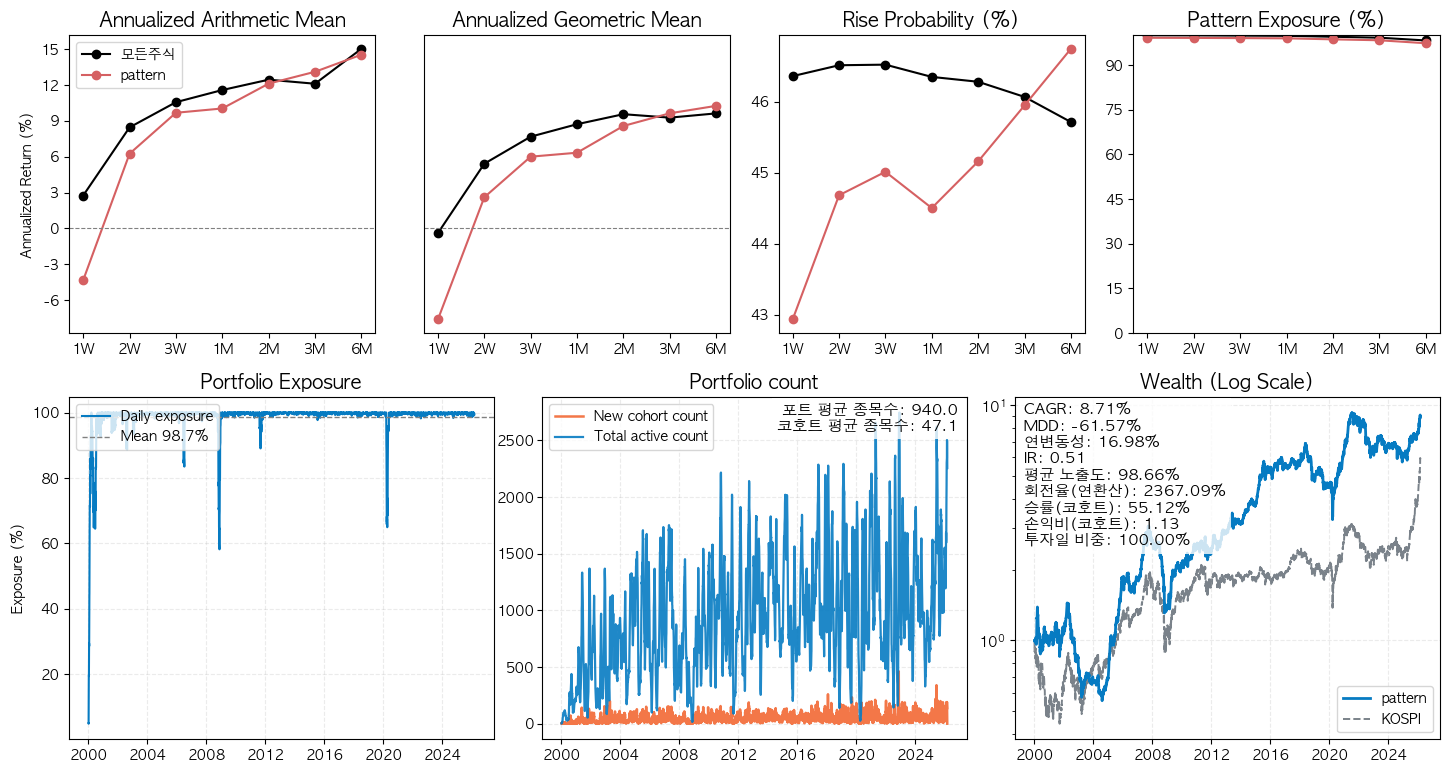

In [6]:
strat = bb.named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 상승추세
* 상승추세 = 200일 이평선이 전일대비 상승

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 29995.64it/s]
pattern | run: 100%|██████████| 6446/6446 [00:03<00:00, 1803.22it/s]


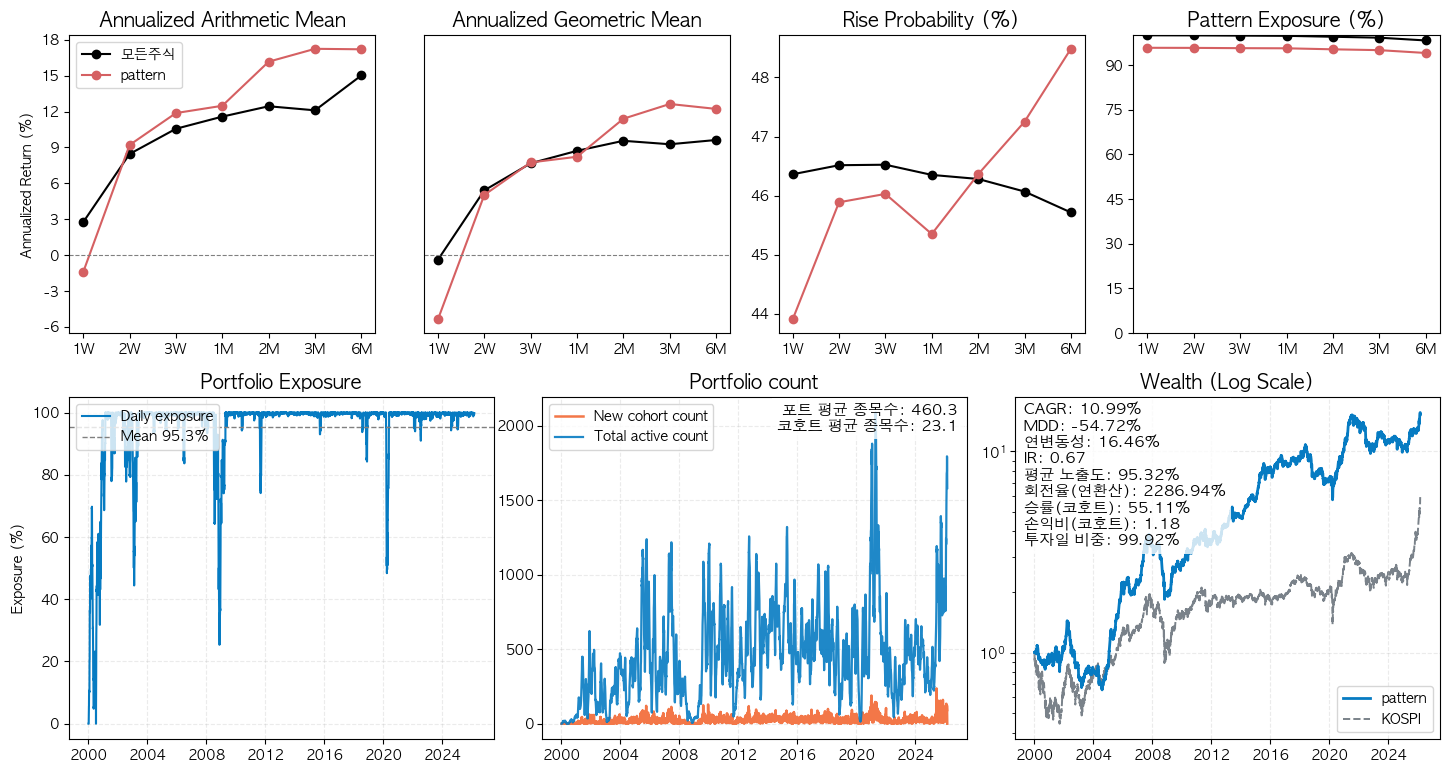

In [11]:
strat = (bb + uptrend).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 52주 고가 근접
* 52주 고가의 90% 수준 내로 진입

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 35335.47it/s]
pattern | run: 100%|██████████| 6446/6446 [00:03<00:00, 1931.10it/s]


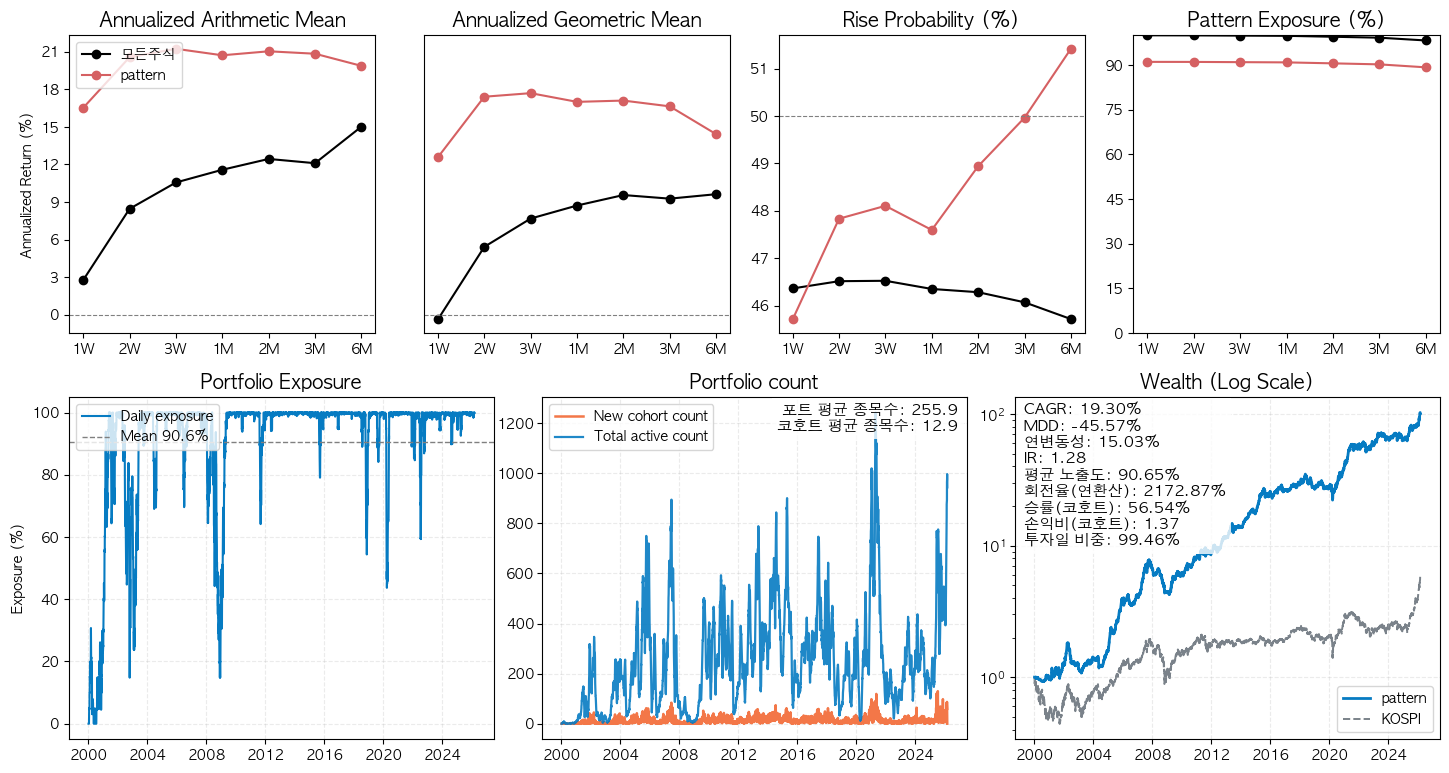

In [12]:
strat = (bb + uptrend + high52w).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) MFI 매수우위
* MFI = 가격과 거래량을 동시에 고려하여 매수/매도 압력 측정 > 50

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 35288.75it/s]
pattern | run: 100%|██████████| 6446/6446 [00:03<00:00, 1910.35it/s]


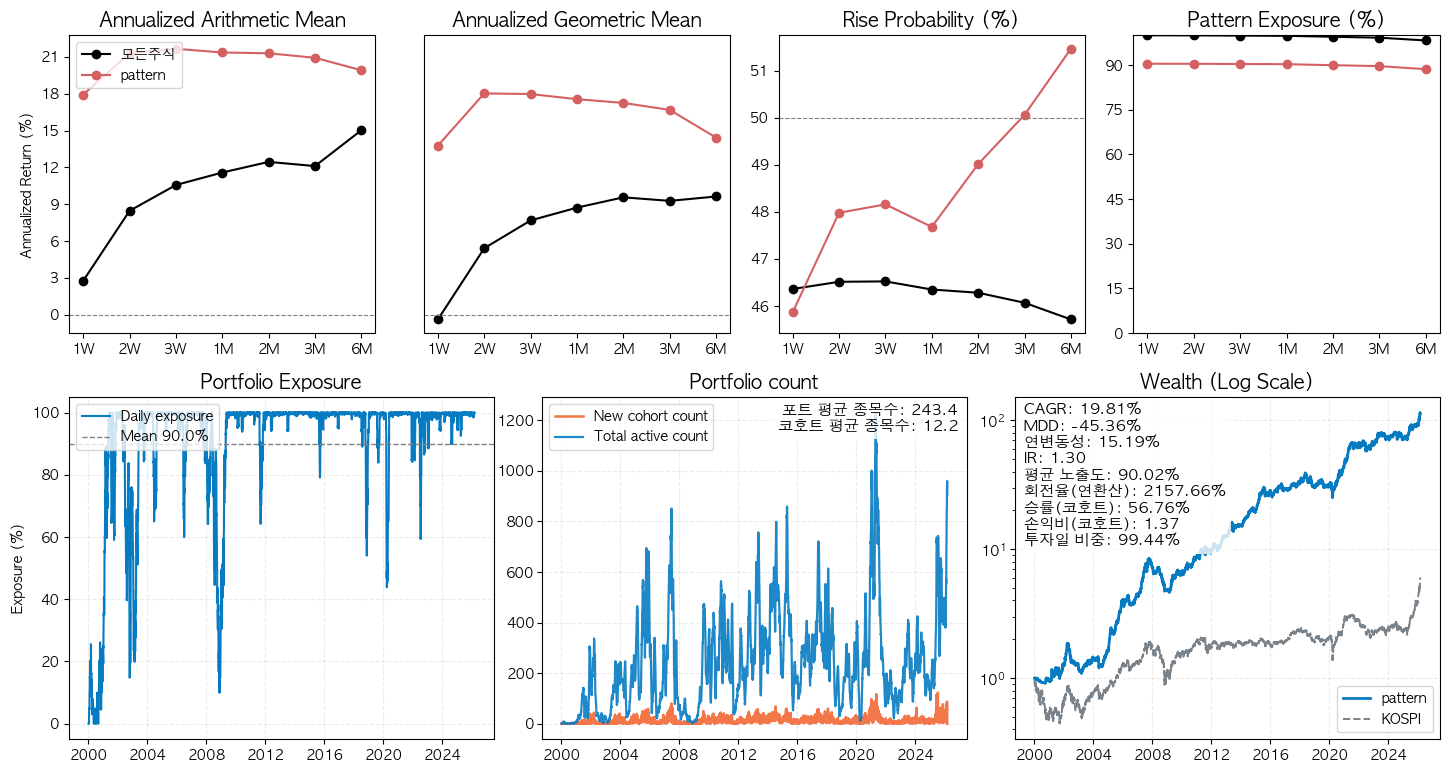

In [13]:
strat = (bb + uptrend + high52w + mfi_high).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 거래량 급증
* 20일 평균거래량에서 50% 이상 급증

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 38577.02it/s]
pattern | run: 100%|██████████| 6446/6446 [00:03<00:00, 2079.24it/s]


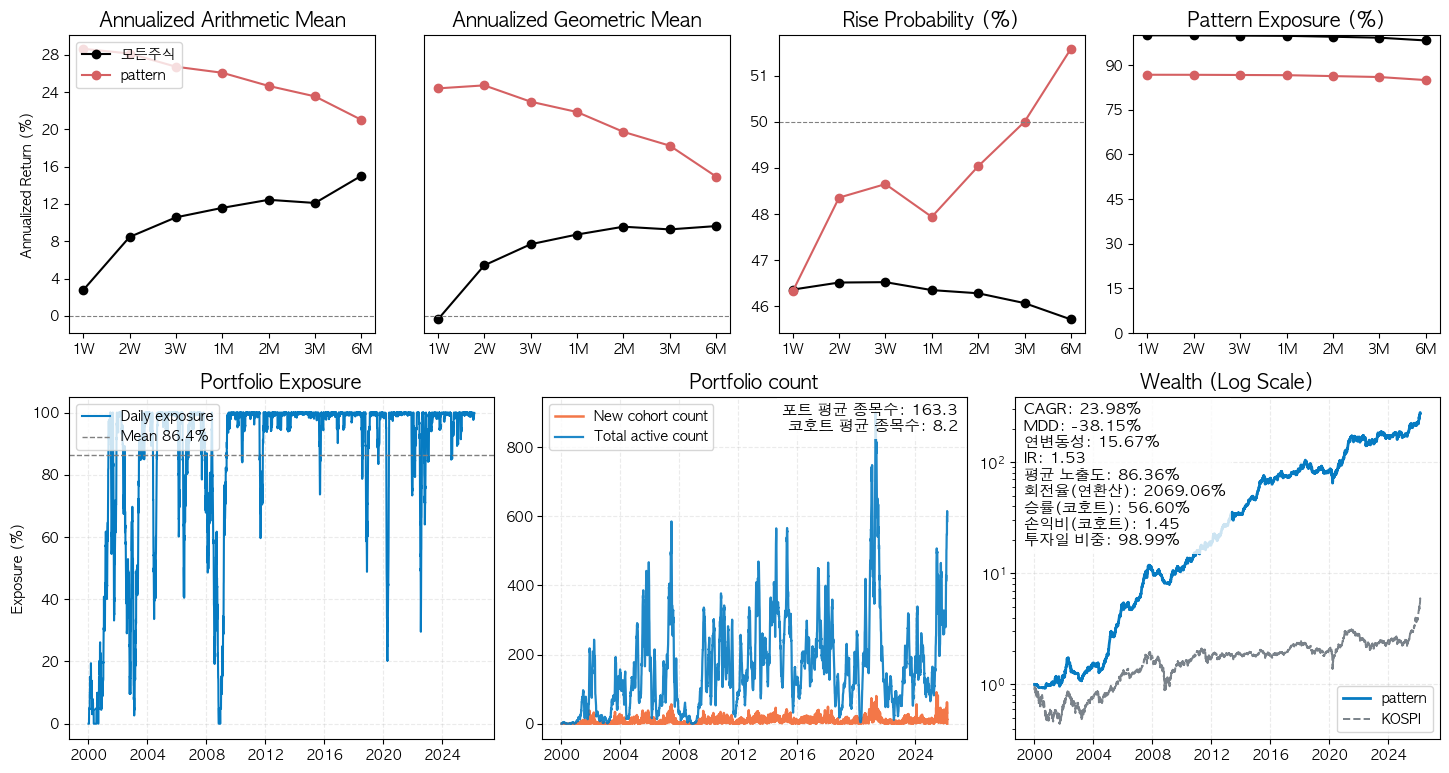

In [14]:
strat = (bb + uptrend + high52w + mfi_high + amt).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 패턴의 특성 강화
* [볼린저밴드] 돌파의 선명성 강화(3일내 최초 돌파) + 폭 축소(5%)
* [거래량] 20일 평균거래량에서 100% 이상 급증

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 49563.27it/s]
pattern | run: 100%|██████████| 6446/6446 [00:02<00:00, 3168.90it/s]


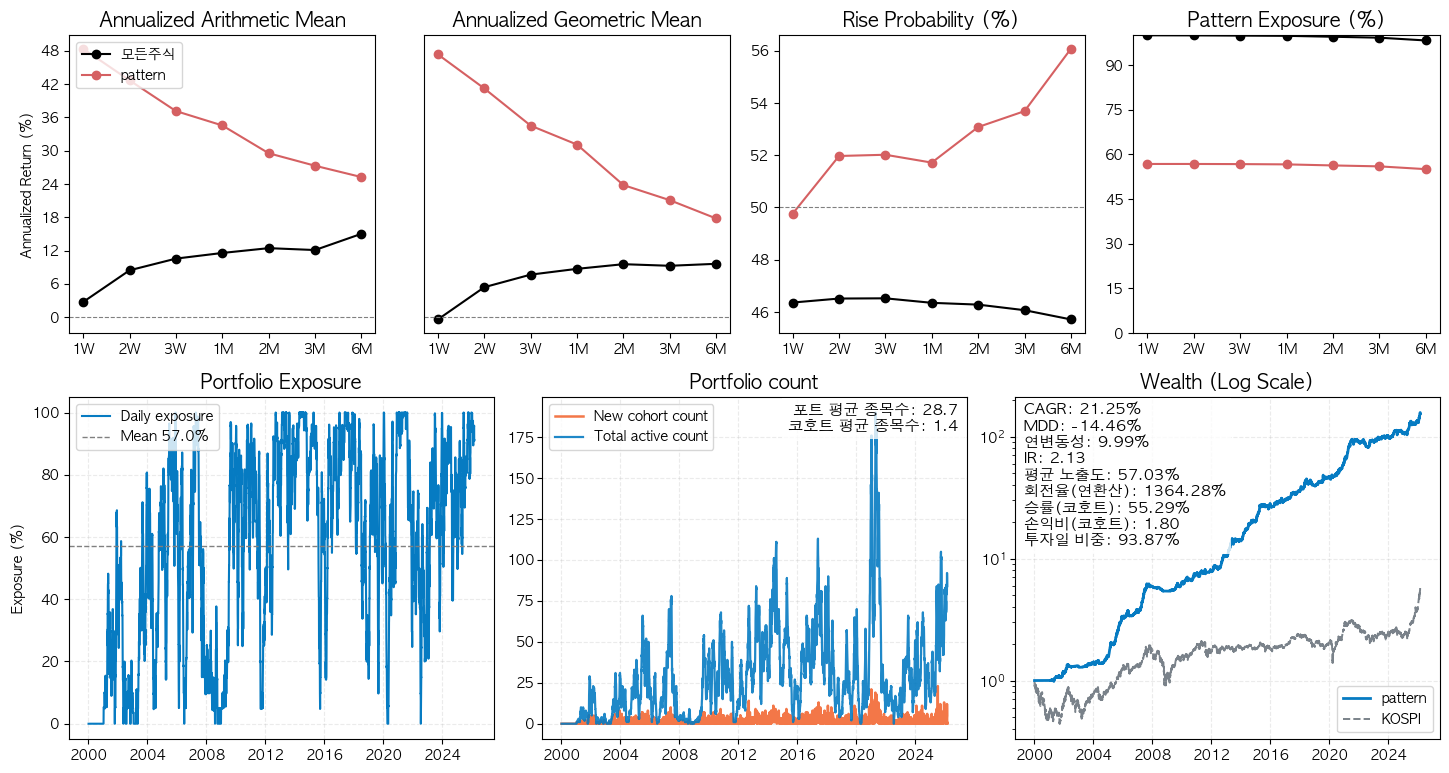

In [15]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 코호트 편입종목 통제
* 각 코호트의 종목수 <= 5개
* 선호기준
    -  시가총액이 클수록
    - 볼린저밴드의 폭이 좁을 수록
    - 거래량 증가의 정도가 클수록
    - 52주 고가의 근접도가 클수록
    - 추세의 강도(기울기)가 클수록
    - MFI가 클수록

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 47414.25it/s]
pattern | run: 100%|██████████| 6446/6446 [00:02<00:00, 3056.53it/s]


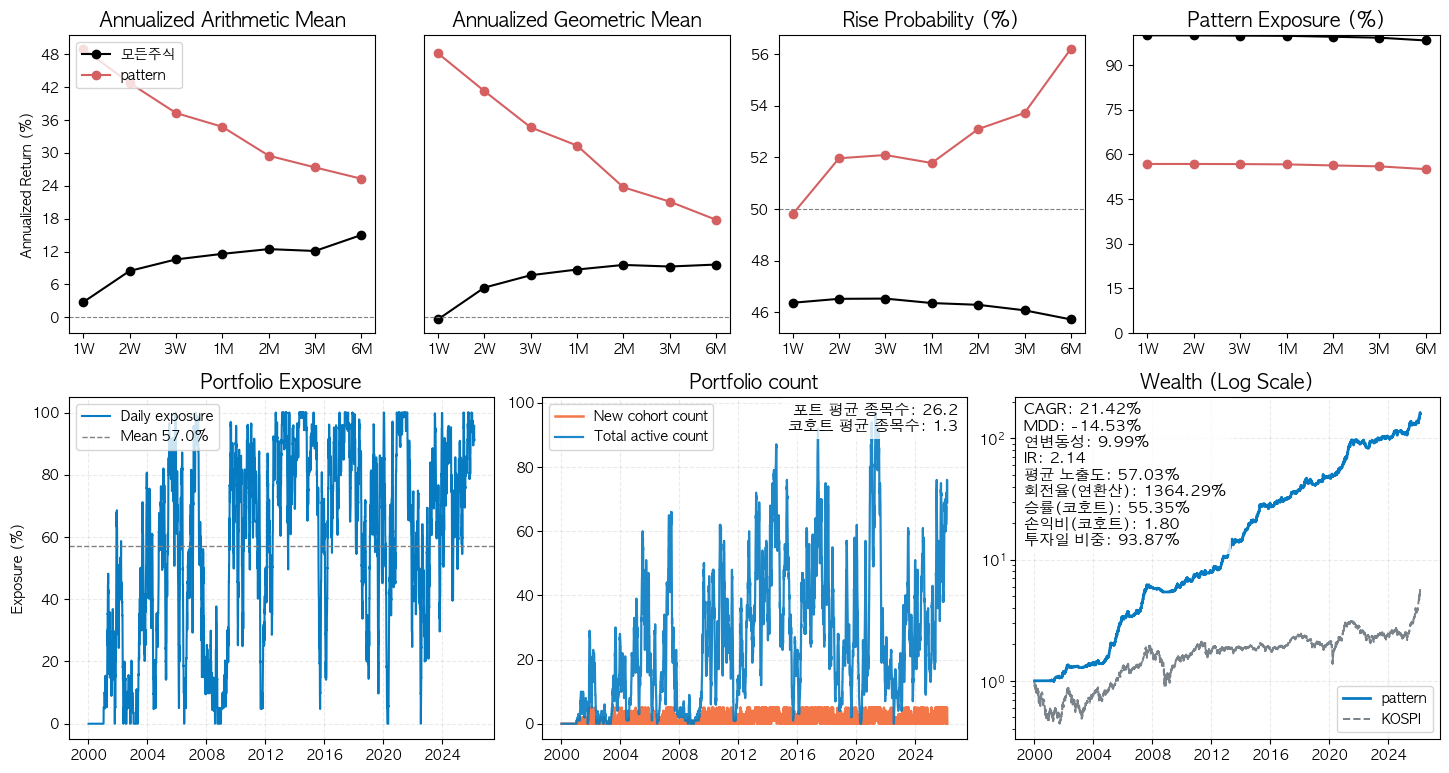

In [80]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='당일종가')
bt.plot(annualized=True, show_kospi=True)

# (+) 익일종가로 매매
* 종가기준 패턴 확인 후, 종가로 매매하는 것은 비현실적 → 익일종가 매매

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 51224.08it/s]
pattern | run: 100%|██████████| 6446/6446 [00:02<00:00, 3186.79it/s]


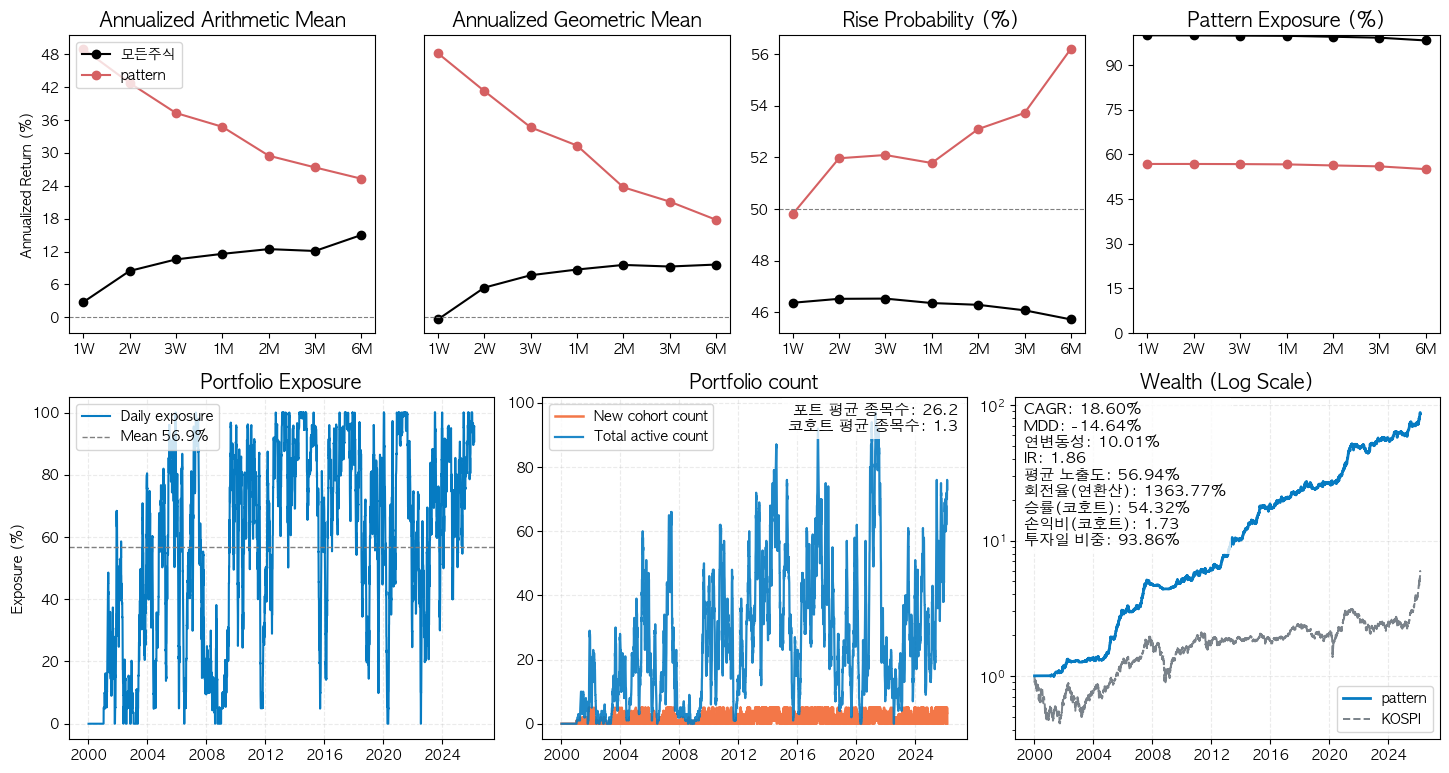

In [85]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)

# (번외) 코호트 10일 보유 + 코호트 종목수 10개 이내

pattern | day: 100%|██████████| 6447/6447 [00:00<00:00, 49580.53it/s]
pattern | run: 100%|██████████| 6446/6446 [00:01<00:00, 5651.07it/s] 


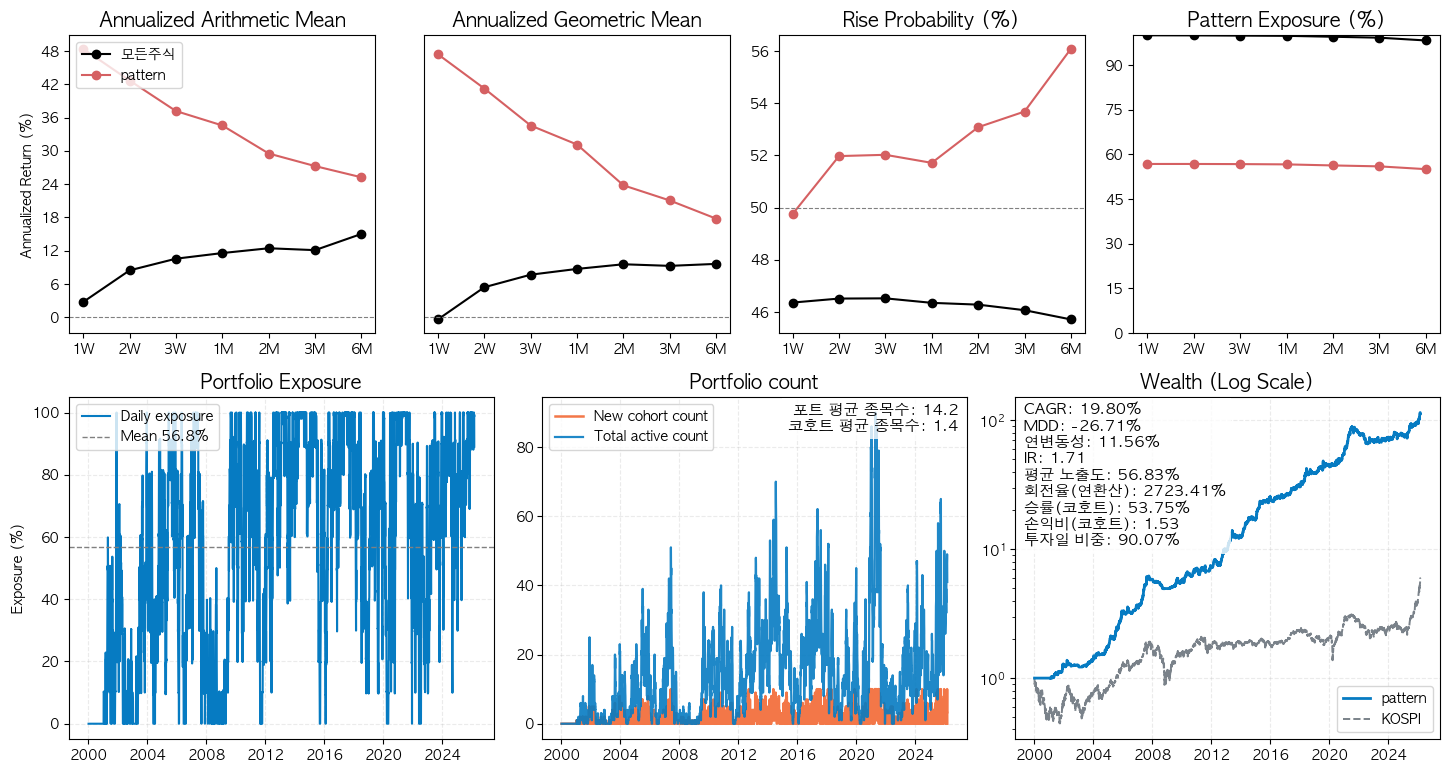

In [86]:
strat = (bb2 + uptrend + high52w + mfi_high + amt2).named('pattern')
strat = strat.rank_by(
    ('stock', 'marketcap.desc'),
    (amt2, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(10)
bt.analyze(strat)
bt.run(pattern="pattern", target_horizon=10, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)

# (번외) 시가총액 1천억 이상으로 제한
* 패턴 출현빈도가 낮아서, 패턴조건은 다소 완화

실행필터 준비 | 필터 마스크: 100%|██████████| 2/2 [00:03<00:00,  1.82s/it]  
pattern: 100%|██████████| 6448/6448 [00:02<00:00, 2966.71it/s]       
pattern | run: 100%|██████████| 6446/6446 [00:02<00:00, 3107.59it/s]


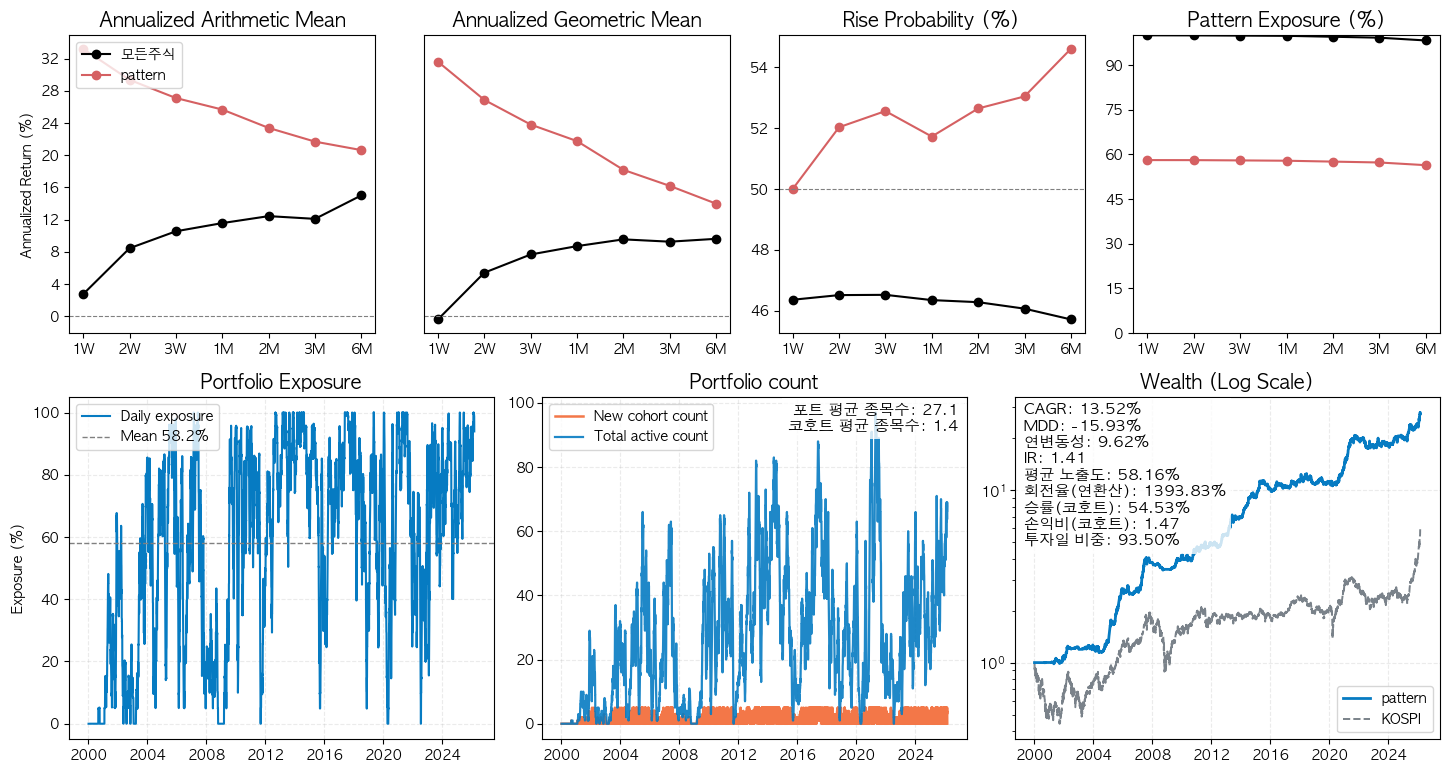

In [98]:
strat = (bb2 + uptrend + high52w + mfi_high + amt).named('pattern')
strat = strat.rank_by(
    # ('stock', 'marketcap.desc'),
    (amt, "ratio.desc"),
    (bb2, "bandwidth.asc"),
    (high52w, "proximity.desc"),
    (uptrend, "ma_slope.desc"),
    (mfi_high, "value.desc"),
).nmax(5)
bt.analyze(strat, filter=Filter(market_cap=[5,6,7,8,9,10]))
bt.run(pattern="pattern", target_horizon=20, trade_price_mode='익일종가')
bt.plot(annualized=True, show_kospi=True)